**1) Importar bibliotecas**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

**2) Fazer upload do arquivo no Colab**

In [62]:
from google.colab import files
uploaded = files.upload()

Saving CIA-1 Dataset - Dataset.csv to CIA-1 Dataset - Dataset (2).csv


In [35]:
df = pd.read_csv("CIA-1 Dataset - Dataset (1).csv")

**3) Ler e visualizar a base**

In [63]:
df.head()

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,vibration_levels,operational_hours,failure_type,has_failure,delta_temperature,hours_group
0,1,M14860,M,298.1,308.6,1551,42.8,42.0,20.0,No Failure,0,10.5,0-50
1,2,L47181,L,298.2,308.7,1408,46.3,52.0,21.0,No Failure,0,10.5,0-50
2,3,L47182,L,298.1,308.5,1498,49.4,44.0,18.0,No Failure,0,10.4,0-50
3,4,L47183,L,298.2,308.6,1433,39.5,52.0,10.0,No Failure,0,10.4,0-50
4,5,L47184,L,298.2,308.7,1408,40.0,44.0,10.0,No Failure,0,10.5,0-50


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   udi                    500 non-null    int64   
 1   product_id             500 non-null    object  
 2   type                   500 non-null    object  
 3   air_temperature_k      500 non-null    float64 
 4   process_temperature_k  500 non-null    float64 
 5   rotational_speed_rpm   500 non-null    int64   
 6   torque_nm              500 non-null    float64 
 7   vibration_levels       500 non-null    float64 
 8   operational_hours      500 non-null    float64 
 9   failure_type           500 non-null    object  
 10  has_failure            500 non-null    int64   
 11  delta_temperature      500 non-null    float64 
 12  hours_group            500 non-null    category
dtypes: category(1), float64(6), int64(3), object(3)
memory usage: 47.7+ KB


In [38]:
df.shape

(500, 10)

**4) Padronizar nomes das colunas**

In [39]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

df.columns

Index(['udi', 'product_id', 'type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'vibration_levels', 'operational_hours', 'failure_type'],
      dtype='object')

**5) Verificação inicial de qualidade dos dados**

In [40]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:")
print(df.duplicated().sum())

Valores nulos por coluna:
udi                      0
product_id               0
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
vibration_levels         0
operational_hours        0
failure_type             0
dtype: int64

Linhas duplicadas:
0


**6) Estatísticas descritivas**

In [41]:
df.describe()

,udi,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,vibration_levels,operational_hours
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,298.097800,308.576400,1540.494000,39.882800,36.904811,81.106840
std,144.481833,0.563071,0.345372,193.658248,9.768592,9.242797,45.904853
min,1.000000,297.200000,307.900000,1208.000000,4.200000,23.000000,10.000000
25%,125.750000,297.500000,308.300000,1424.750000,33.575000,31.183871,36.202500
50%,250.500000,298.100000,308.500000,1498.000000,40.350000,35.000000,77.575000
75%,375.250000,298.625000,308.800000,1604.500000,46.225000,44.000000,121.097500
max,500.000000,299.100000,309.500000,2874.000000,65.700000,55.000000,165.330000


**7) Verificar categorias**

In [42]:
print("Tipos de máquina:")
print(df["type"].value_counts())

print("\nTipos de falha:")
print(df["failure_type"].value_counts())

Tipos de máquina:
type
L    307
M    139
H     54
Name: count, dtype: int64

Tipos de falha:
failure_type
No Failure            467
Tool Wear Failure      19
Overstrain Failure      8
Power Failure           6
Name: count, dtype: int64


**8) Criar variável binária de falha**

In [43]:
df["has_failure"] = np.where(df["failure_type"] == "No Failure", 0, 1)
df[["failure_type", "has_failure"]].head()

,failure_type,has_failure
0,No Failure,0
1,No Failure,0
2,No Failure,0
3,No Failure,0
4,No Failure,0


**9) Histogramas das variáveis numéricas**

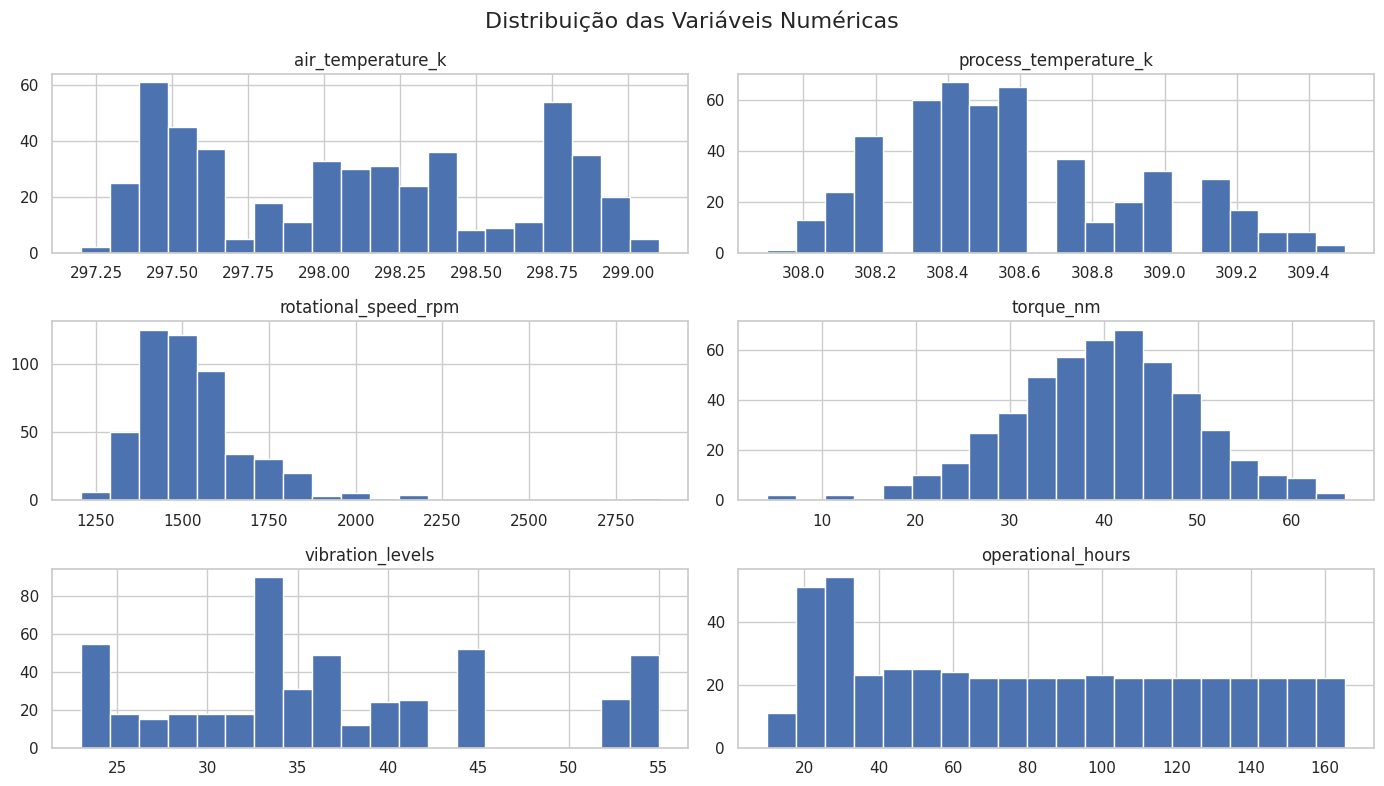

In [44]:
colunas_numericas = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "vibration_levels",
    "operational_hours"
]

df[colunas_numericas].hist(bins=20, figsize=(14, 8))
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

**10) Boxplots para detectar outliers**

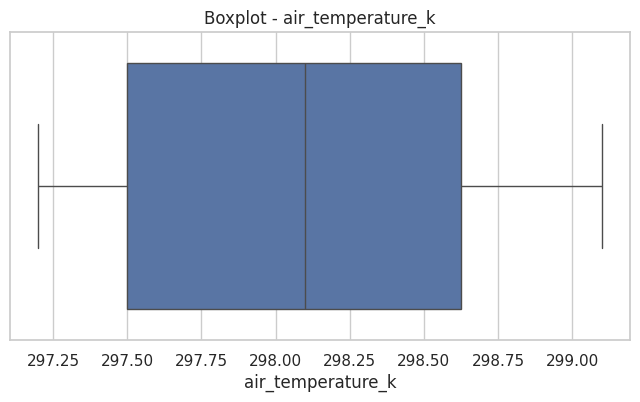

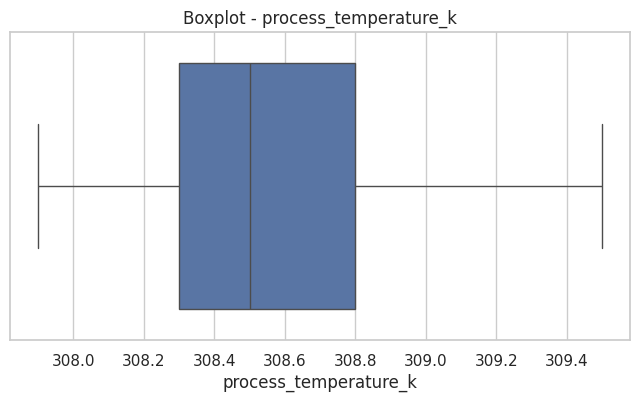

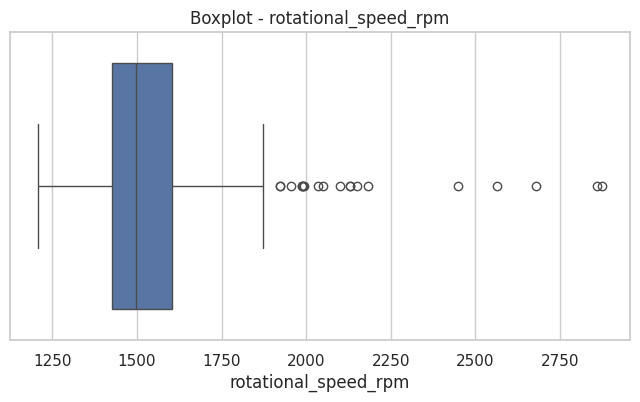

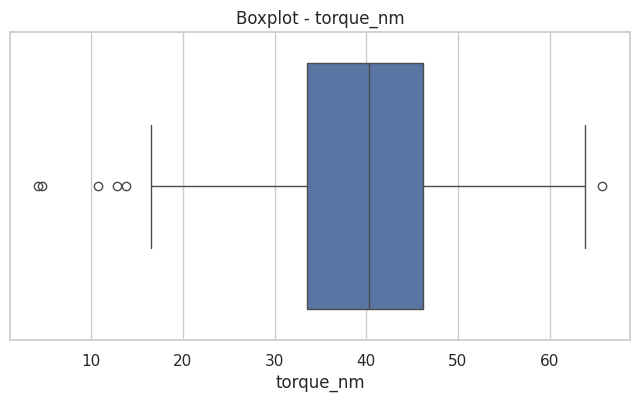

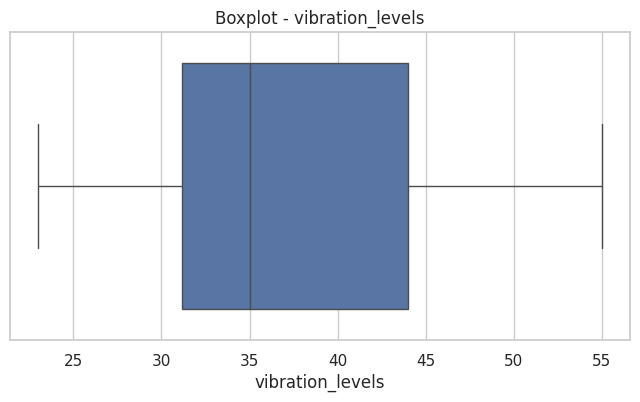

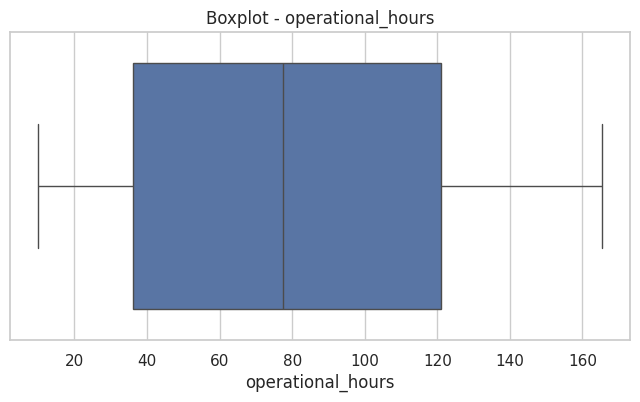

In [45]:
for col in colunas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

**11) Matriz de correlação**

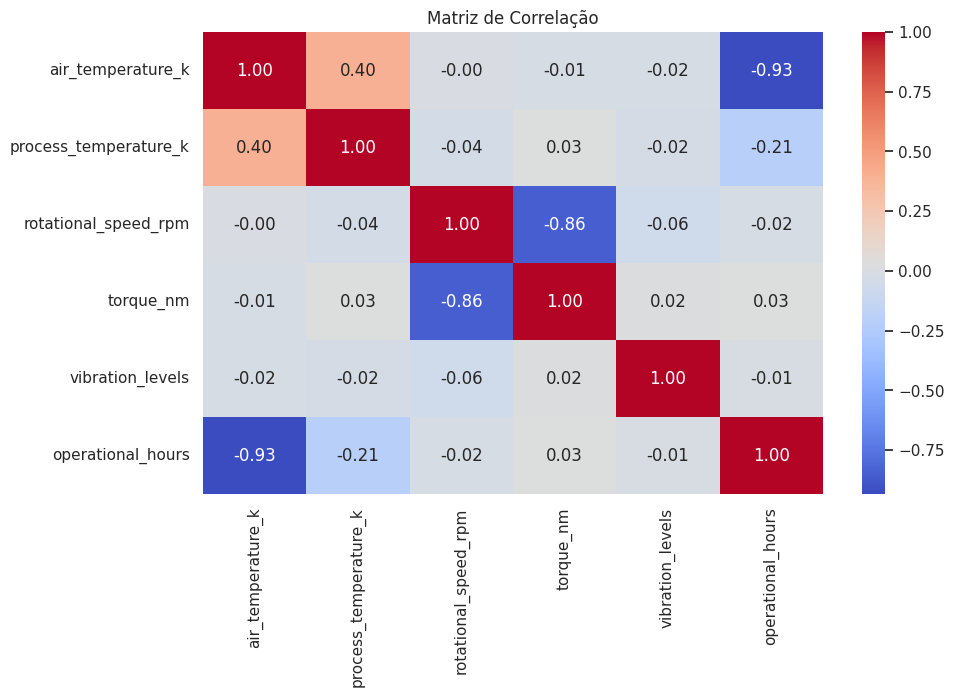

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

**12) Contagem dos tipos de falha**

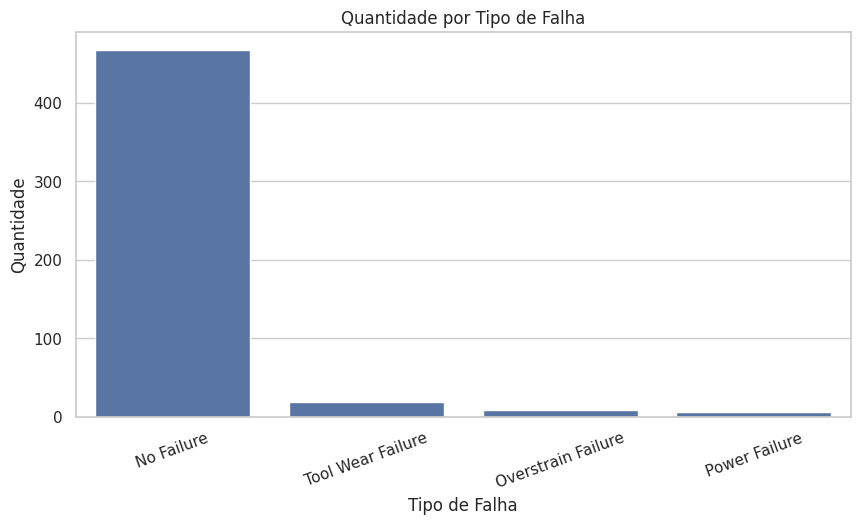

In [47]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="failure_type", order=df["failure_type"].value_counts().index)
plt.title("Quantidade por Tipo de Falha")
plt.xlabel("Tipo de Falha")
plt.ylabel("Quantidade")
plt.xticks(rotation=20)
plt.show()

**13) Comparar variáveis entre máquina com falha e sem falha**

**Rotação**

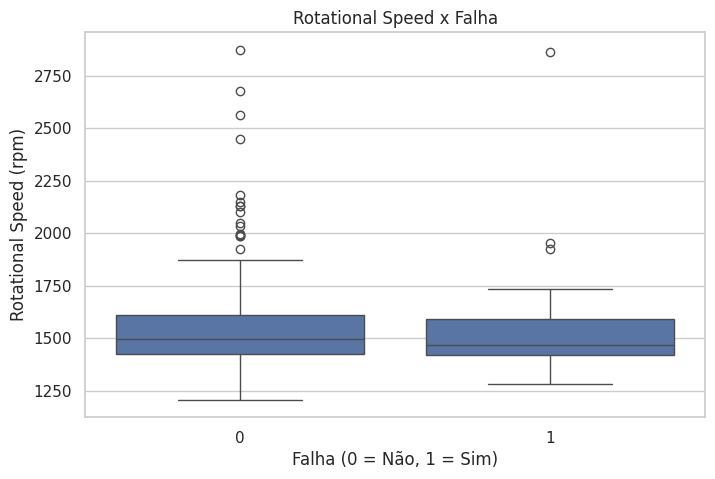

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="has_failure", y="rotational_speed_rpm")
plt.title("Rotational Speed x Falha")
plt.xlabel("Falha (0 = Não, 1 = Sim)")
plt.ylabel("Rotational Speed (rpm)")
plt.show()

**Torque**

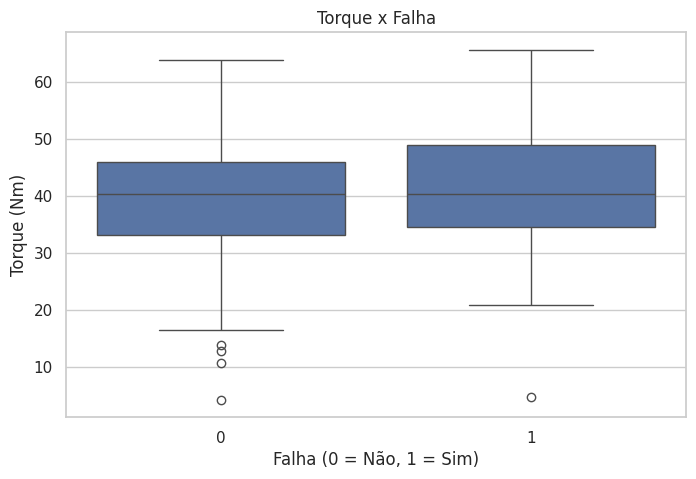

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="has_failure", y="torque_nm")
plt.title("Torque x Falha")
plt.xlabel("Falha (0 = Não, 1 = Sim)")
plt.ylabel("Torque (Nm)")
plt.show()

**Vibração**

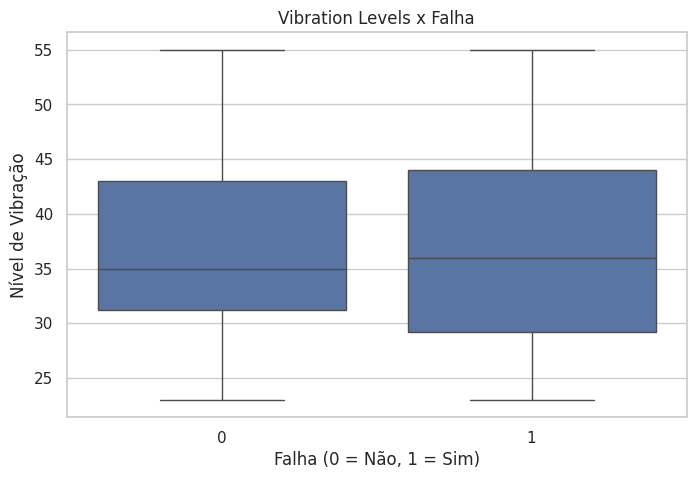

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="has_failure", y="vibration_levels")
plt.title("Vibration Levels x Falha")
plt.xlabel("Falha (0 = Não, 1 = Sim)")
plt.ylabel("Nível de Vibração")
plt.show()

**Horas operacionais**

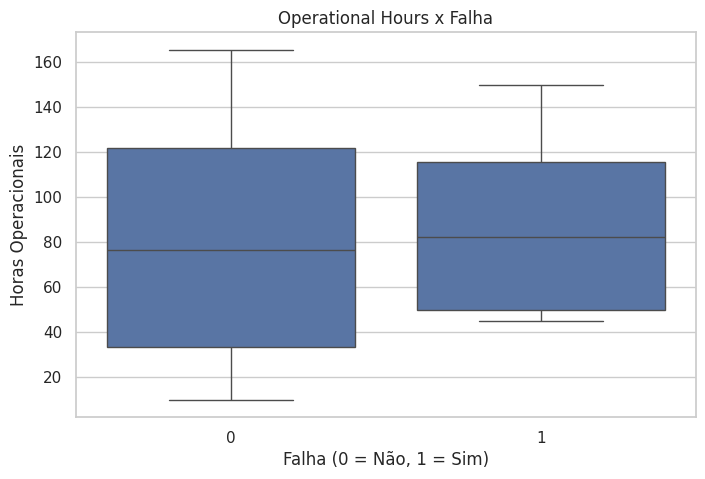

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="has_failure", y="operational_hours")
plt.title("Operational Hours x Falha")
plt.xlabel("Falha (0 = Não, 1 = Sim)")
plt.ylabel("Horas Operacionais")
plt.show()

**14) Comparar por tipo de falha**

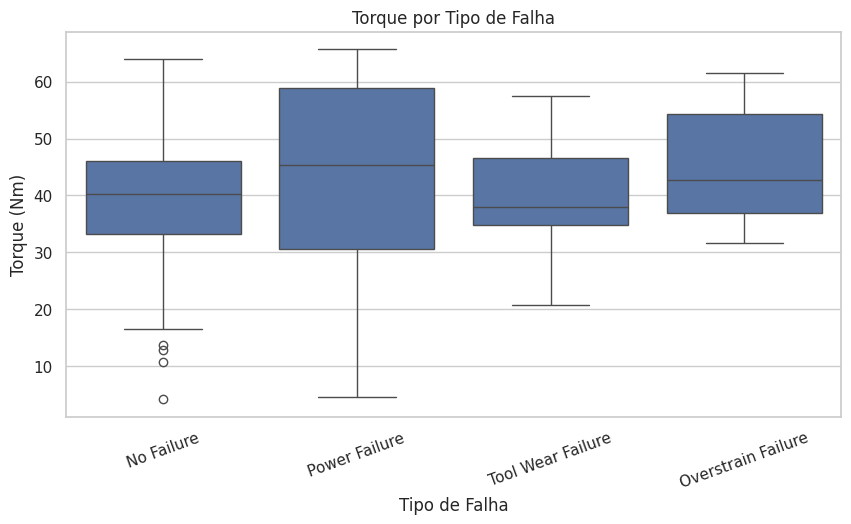

In [52]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="failure_type", y="torque_nm")
plt.title("Torque por Tipo de Falha")
plt.xlabel("Tipo de Falha")
plt.ylabel("Torque (Nm)")
plt.xticks(rotation=20)
plt.show()

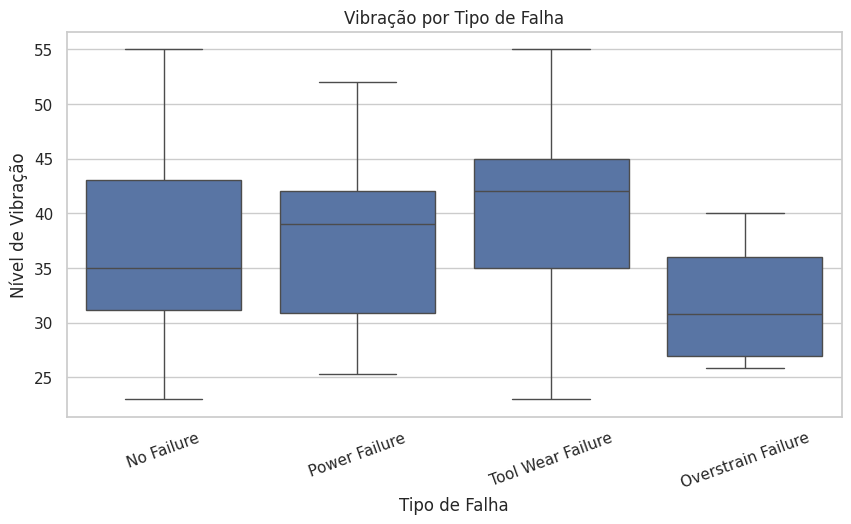

In [53]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="failure_type", y="vibration_levels")
plt.title("Vibração por Tipo de Falha")
plt.xlabel("Tipo de Falha")
plt.ylabel("Nível de Vibração")
plt.xticks(rotation=20)
plt.show()

**15) Relação entre rotação e torque**

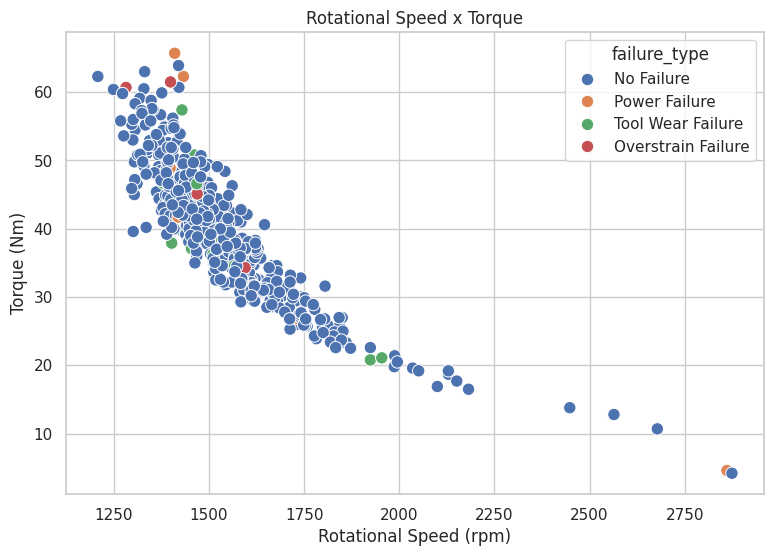

In [54]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="rotational_speed_rpm",
    y="torque_nm",
    hue="failure_type",
    s=80
)
plt.title("Rotational Speed x Torque")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.show()

**16) Relação entre vibração e horas operacionais**

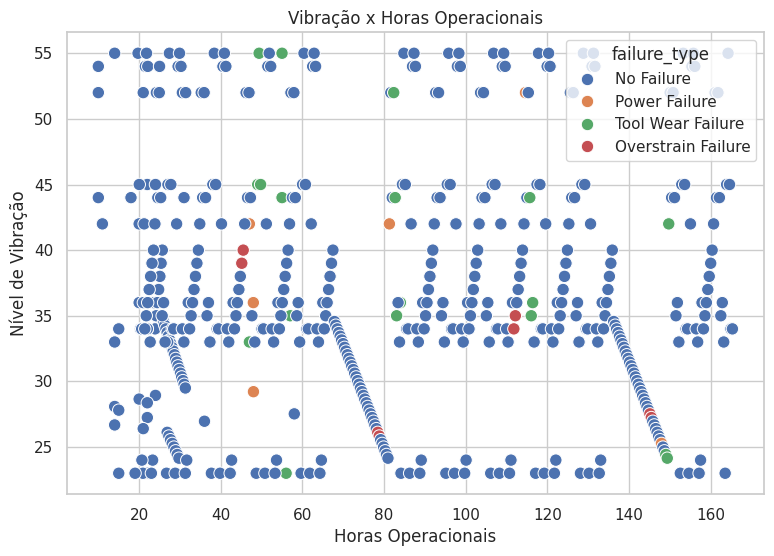

In [55]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="operational_hours",
    y="vibration_levels",
    hue="failure_type",
    s=80
)
plt.title("Vibração x Horas Operacionais")
plt.xlabel("Horas Operacionais")
plt.ylabel("Nível de Vibração")
plt.show()

**17) Comparação por tipo de máquina**

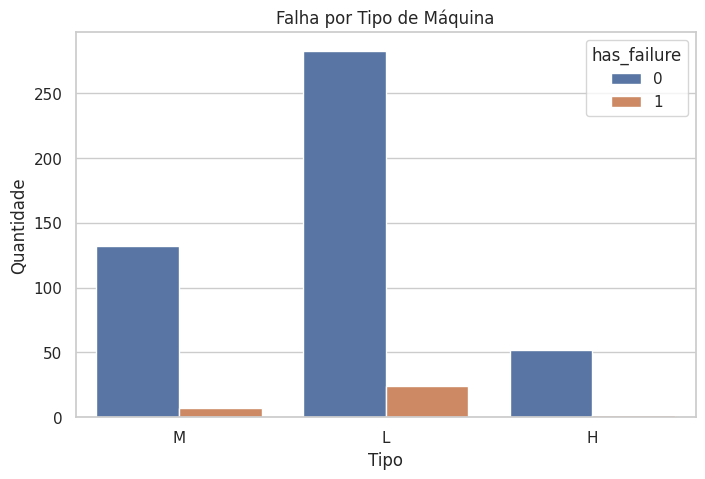

In [56]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type", hue="has_failure")
plt.title("Falha por Tipo de Máquina")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.show()

**18) Criar algumas features novas**

**Diferença de temperatura**

In [57]:
df["delta_temperature"] = df["process_temperature_k"] - df["air_temperature_k"]
df[["air_temperature_k", "process_temperature_k", "delta_temperature"]].head()

,air_temperature_k,process_temperature_k,delta_temperature
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


**Faixas de horas operacionais**

In [58]:
df["hours_group"] = pd.cut(
    df["operational_hours"],
    bins=[0, 50, 100, 150, 200, 300],
    labels=["0-50", "51-100", "101-150", "151-200", "201-300"]
)

df["hours_group"].value_counts().sort_index()

,count
hours_group,
0-50,167
51-100,148
101-150,141
151-200,44
201-300,0


**Falhas por faixa de horas**

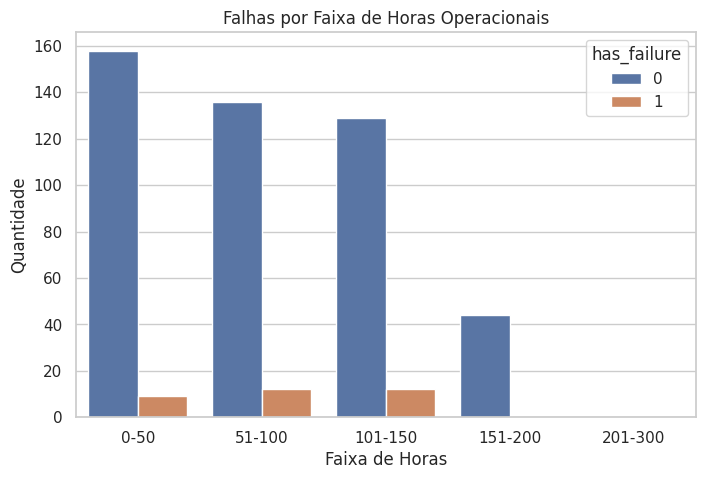

In [59]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hours_group", hue="has_failure")
plt.title("Falhas por Faixa de Horas Operacionais")
plt.xlabel("Faixa de Horas")
plt.ylabel("Quantidade")
plt.show()

**19) Detectar outliers com IQR**

In [60]:
def detectar_outliers_iqr(dataframe, coluna):
    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[coluna] < limite_inferior) |
        (dataframe[coluna] > limite_superior)
    ]

    return outliers

for col in colunas_numericas:
    outliers = detectar_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

air_temperature_k: 0 outliers
process_temperature_k: 0 outliers
rotational_speed_rpm: 19 outliers
torque_nm: 6 outliers
vibration_levels: 0 outliers
operational_hours: 0 outliers


**20) Salvar base tratada**

In [61]:
df.to_csv("dataset_tratado.csv", index=False)
print("Arquivo salvo com sucesso!")

Arquivo salvo com sucesso!
